In [1]:
import pandas as pd

In [2]:
final_table = pd.read_csv('final_table.csv',index_col = 0)
final_table.shape

(85426, 7)

In [3]:
final_table.dropna(inplace=True)
final_table.shape

(44980, 7)

In [4]:
from sklearn.model_selection import train_test_split

# Isolate columns from our 44,986 clean records
X = final_table[['Year', 'Area', 'Item', 'Area_Harvested_ha', 'Yield_kg_ha']]
y = final_table['Production_tons']

# Step 1: Separate the 20% final holdout Test vault
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Step 2: Split the remainder into Train (60%) and Validation (20%)
X_train, X_validate, y_train, y_validate = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("📂 SPLIT COMPLETION REGISTER:")
print(f"• Training Pool (60%):   {X_train.shape[0]} rows")
print(f"• Validation Pool (20%): {X_validate.shape[0]} rows")
print(f"• Holdout Test Pool (20%): {X_test.shape[0]} rows")

📂 SPLIT COMPLETION REGISTER:
• Training Pool (60%):   26988 rows
• Validation Pool (20%): 8996 rows
• Holdout Test Pool (20%): 8996 rows


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define column groups
numeric_cols = ['Year', 'Area_Harvested_ha', 'Yield_kg_ha']
categorical_cols = ['Area', 'Item']

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

ArithmeticError
# Learn from the training data
preprocessor.fit(X_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [10]:
print(X_train.head())

       Year        Area                                     Item  \
68764  2019    Slovakia                             Green garlic   
55274  2022       Niger                               Beans, dry   
68046  2021  Seychelles                               Pineapples   
2472   2022   Argentina                       Rape or colza seed   
83622  2022    Viet Nam  Cinnamon and cinnamon-tree flowers, raw   

       Area_Harvested_ha  Yield_kg_ha  
68764              100.0       5900.0  
55274            36143.0        517.8  
68046                2.0      19297.4  
2472             25835.0       2048.2  
83622           183544.0        354.1  


In [25]:
X_train_transformed = preprocessor.transform(X_train)
X_validate_transformed = preprocessor.transform(X_validate)
X_test_transformed = preprocessor.transform(X_test)

In [13]:
# 1. Convert your mathematical sparse matrix into a standard array
dense_matrix = X_train_transformed.toarray()

# 2. Reconstruct all 360 dynamic column names from your preprocessor
numeric_feature_names = numeric_cols  # ['Year', 'Area_Harvested_ha', 'Yield_kg_ha']
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_column_names = list(numeric_feature_names) + list(categorical_feature_names)

# 3. Pack everything back into an easily readable DataFrame
transformed_df = pd.DataFrame(dense_matrix, columns=all_column_names)

transformed_df

,Year,Area_Harvested_ha,Yield_kg_ha,Area_Afghanistan,Area_Albania,Area_Algeria,Area_Angola,Area_Antigua and Barbuda,Area_Argentina,Area_Armenia,...,"Item_True hemp, raw or retted",Item_Tung nuts,Item_Unmanufactured tobacco,"Item_Vanilla, raw",Item_Vetches,"Item_Walnuts, in shell",Item_Watermelons,Item_Wheat,Item_Yams,Item_Yautia
0,-1.422951,-0.122104,-0.250880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.706544,-0.097789,-0.447810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.003288,-0.122170,0.239319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.706544,-0.104743,-0.391814,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.706544,0.001650,-0.453799,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26983,-0.003288,-0.122166,-0.393577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26984,-1.422951,-0.019853,-0.244817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26985,1.416375,0.439018,1.259369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26986,-1.422951,-0.121362,-0.345400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Initialize and train the focused Random Forest model on your training DataFrame
print("🏋️ Training focused Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(transformed_df, y_train)
print("🎯 Training complete!\n")

# 2. Append true target and predictions to your training DataFrame
transformed_df['Target_Actual_Tons'] = y_train.values
transformed_df['Model_Predicted_Tons'] = rf_model.predict(transformed_df.drop(columns=['Target_Actual_Tons'], errors='ignore'))


🏋️ Training focused Random Forest Regressor...


🎯 Training complete!



In [21]:
transformed_df

,Year,Area_Harvested_ha,Yield_kg_ha,Area_Afghanistan,Area_Albania,Area_Algeria,Area_Angola,Area_Antigua and Barbuda,Area_Argentina,Area_Armenia,...,Item_Unmanufactured tobacco,"Item_Vanilla, raw",Item_Vetches,"Item_Walnuts, in shell",Item_Watermelons,Item_Wheat,Item_Yams,Item_Yautia,Target_Actual_Tons,Model_Predicted_Tons
0,-1.422951,-0.122104,-0.250880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,590.00,5.933762e+02
1,0.706544,-0.097789,-0.447810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18716.37,1.889217e+04
2,-0.003288,-0.122170,0.239319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.74,3.465020e+01
3,0.706544,-0.104743,-0.391814,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52915.00,5.269440e+04
4,0.706544,0.001650,-0.453799,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65000.00,6.542650e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26983,-0.003288,-0.122166,-0.393577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.00,1.697660e+01
26984,-1.422951,-0.019853,-0.244817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,919978.00,9.220555e+05
26985,1.416375,0.439018,1.259369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39244168.23,3.885878e+07
26986,-1.422951,-0.121362,-0.345400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3980.00,4.015025e+03


In [26]:
# 3. Reconstruct the Validation DataFrame exactly like you did for training
dense_matrix_val = X_validate_transformed.toarray()
validate_df = pd.DataFrame(dense_matrix_val, columns=all_column_names)
validate_preds = rf_model.predict(validate_df)
validate_df['Target_Actual_Tons'] = y_validate.values
validate_df['Model_Predicted_Tons'] = validate_preds

In [27]:
validate_df

,Year,Area_Harvested_ha,Yield_kg_ha,Area_Afghanistan,Area_Albania,Area_Algeria,Area_Angola,Area_Antigua and Barbuda,Area_Argentina,Area_Armenia,...,Item_Unmanufactured tobacco,"Item_Vanilla, raw",Item_Vetches,"Item_Walnuts, in shell",Item_Watermelons,Item_Wheat,Item_Yams,Item_Yautia,Target_Actual_Tons,Model_Predicted_Tons
0,-1.422951,-0.121953,-0.128420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2996.00,3.080762e+03
1,1.416375,-0.073831,-0.274944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,375647.95,3.684690e+05
2,-0.713119,-0.121361,-0.140007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10729.00,1.074673e+04
3,1.416375,-0.081088,-0.361434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,175300.00,1.800852e+05
4,1.416375,-0.024110,-0.412842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,214190.00,2.084205e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8991,-0.003288,-0.121605,-0.258948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4769.38,4.788418e+03
8992,0.706544,-0.121821,0.121484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8360.00,8.223029e+03
8993,1.416375,-0.121740,16.095542,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,289700.00,2.953288e+05
8994,-0.713119,-0.121941,-0.097805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3434.00,3.374386e+03


In [28]:
# 4. Reconstruct the Holdout Test DataFrame exactly like you did for training
dense_matrix_test = X_test_transformed.toarray()
test_df = pd.DataFrame(dense_matrix_test, columns=all_column_names)
test_preds = rf_model.predict(test_df)
test_df['Target_Actual_Tons'] = y_test.values
test_df['Model_Predicted_Tons'] = test_preds

In [29]:
# 5. Print out final verification diagnostics
print("==========================================================================")
print("🛡️ GENERALIZATION ACCURACY SCORES")
print("==========================================================================")
print(f"• Training Set R²:     {r2_score(y_train, transformed_df['Model_Predicted_Tons']):.4f}")
print(f"• Validation Set R²:   {r2_score(y_validate, validate_preds):.4f}")
print(f"• Holdout Test Set R²:  {r2_score(y_test, test_preds):.4f}")
print("==========================================================================\n")

print("👀 Tail snippet of your enriched holdout test DataFrame (test_df):")
print(test_df[['Year', 'Area_Harvested_ha', 'Target_Actual_Tons', 'Model_Predicted_Tons']].tail(5))

🛡️ GENERALIZATION ACCURACY SCORES
• Training Set R²:     0.9925
• Validation Set R²:   0.9711
• Holdout Test Set R²:  0.9686

👀 Tail snippet of your enriched holdout test DataFrame (test_df):
          Year  Area_Harvested_ha  Target_Actual_Tons  Model_Predicted_Tons
8991  0.706544          -0.094071           509781.46           509133.3900
8992 -1.422951          -0.053718           531122.00           541717.4108
8993 -0.713119          -0.072412            23931.00            22944.3716
8994  0.706544          -0.122020             2568.52             2571.5334
8995 -0.713119          -0.122147              420.34              422.2324


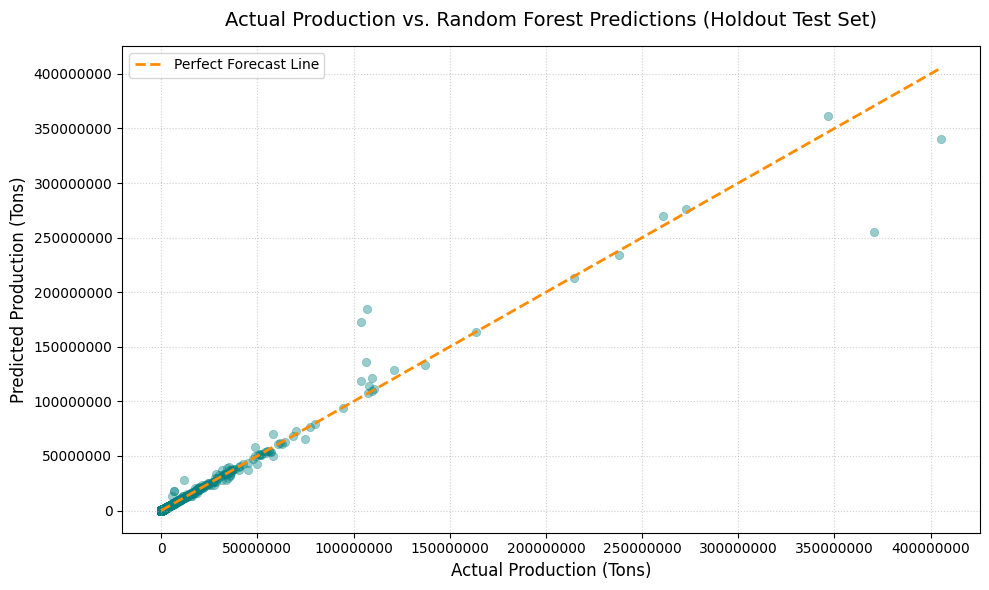

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot the predictions as dots
sns.scatterplot(
    x=test_df['Target_Actual_Tons'], 
    y=test_df['Model_Predicted_Tons'], 
    alpha=0.4, 
    color='teal',
    edgecolor=None
)

# Draw a reference line showing what 100% perfect predictions would look like
max_val = max(test_df['Target_Actual_Tons'].max(), test_df['Model_Predicted_Tons'].max())
plt.plot([0, max_val], [0, max_val], color='darkorange', linestyle='--', linewidth=2, label='Perfect Forecast Line')

plt.title('Actual Production vs. Random Forest Predictions (Holdout Test Set)', fontsize=14, pad=15)
plt.xlabel('Actual Production (Tons)', fontsize=12)
plt.ylabel('Predicted Production (Tons)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both') # Removes confusing scientific notation
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
from sklearn.linear_model import Ridge
import pandas as pd
from sklearn.metrics import r2_score

# 1. Initialize and train the Linear Regression (Ridge) model on your training DataFrame
print("🏋️ Training baseline Linear Regression (Ridge) model...")
lr_model = Ridge(alpha=1.0)
lr_model.fit(transformed_df.drop(columns=['Target_Actual_Tons', 'Model_Predicted_Tons'], errors='ignore'), y_train)
print("🎯 Training complete!\n")

# 2. Reconstruct the clean, distinct DataFrames for all three portfolios
# Training
lr_train_df = pd.DataFrame(X_train_transformed.toarray(), columns=all_column_names)
lr_train_preds = lr_model.predict(lr_train_df)
lr_train_df['Target_Actual_Tons'] = y_train.values
lr_train_df['Model_Predicted_Tons'] = lr_train_preds

# Validation
lr_validate_df = pd.DataFrame(X_validate_transformed.toarray(), columns=all_column_names)
lr_validate_preds = lr_model.predict(lr_validate_df)
lr_validate_df['Target_Actual_Tons'] = y_validate.values
lr_validate_df['Model_Predicted_Tons'] = lr_validate_preds

# Holdout Test
lr_test_df = pd.DataFrame(X_test_transformed.toarray(), columns=all_column_names)
lr_test_preds = lr_model.predict(lr_test_df)
lr_test_df['Target_Actual_Tons'] = y_test.values
lr_test_df['Model_Predicted_Tons'] = lr_test_preds

# 3. Print out the formal Linear Regression diagnostics
print("==========================================================================")
print("📉 LINEAR REGRESSION GENERALIZATION ACCURACY SCORES")
print("==========================================================================")
print(f"• Training Set R²:     {r2_score(y_train, lr_train_preds):.4f}")
print(f"• Validation Set R²:   {r2_score(y_validate, lr_validate_preds):.4f}")
print(f"• Holdout Test Set R²:  {r2_score(y_test, lr_test_preds):.4f}")
print("==========================================================================\n")

print("👀 Tail snippet of your enriched Linear Regression holdout test DataFrame (lr_test_df):")
print(lr_test_df[['Year', 'Area_Harvested_ha', 'Target_Actual_Tons', 'Model_Predicted_Tons']].tail(5))

🏋️ Training baseline Linear Regression (Ridge) model...
🎯 Training complete!

📉 LINEAR REGRESSION GENERALIZATION ACCURACY SCORES
• Training Set R²:     0.4367
• Validation Set R²:   0.4842
• Holdout Test Set R²:  0.4879

👀 Tail snippet of your enriched Linear Regression holdout test DataFrame (lr_test_df):
          Year  Area_Harvested_ha  Target_Actual_Tons  Model_Predicted_Tons
8991  0.706544          -0.094071           509781.46          6.509419e+05
8992 -1.422951          -0.053718           531122.00          3.573644e+05
8993 -0.713119          -0.072412            23931.00         -1.685230e+06
8994  0.706544          -0.122020             2568.52          9.301636e+05
8995 -0.713119          -0.122147              420.34         -3.497677e+05


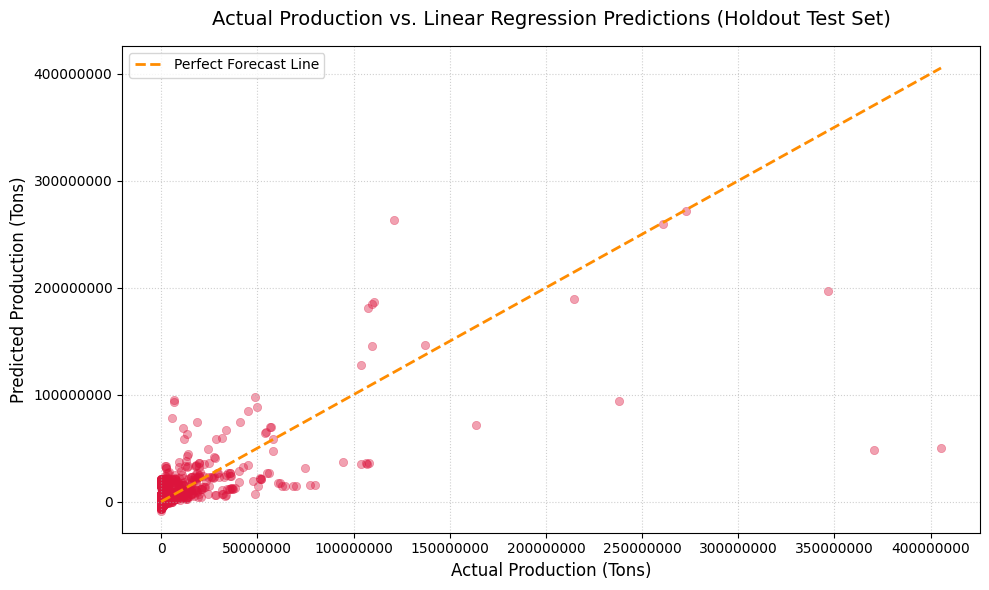

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot the Linear Regression predictions as dots
sns.scatterplot(
    x=lr_test_df['Target_Actual_Tons'], 
    y=lr_test_df['Model_Predicted_Tons'], 
    alpha=0.4, 
    color='crimson',  # Distinct color to tell the models apart
    edgecolor=None
)

# Draw the reference line showing what 100% perfect predictions would look like
max_val = max(lr_test_df['Target_Actual_Tons'].max(), lr_test_df['Model_Predicted_Tons'].max())
plt.plot([0, max_val], [0, max_val], color='darkorange', linestyle='--', linewidth=2, label='Perfect Forecast Line')

plt.title('Actual Production vs. Linear Regression Predictions (Holdout Test Set)', fontsize=14, pad=15)
plt.xlabel('Actual Production (Tons)', fontsize=12)
plt.ylabel('Predicted Production (Tons)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both') # Removes scientific notation
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()